In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

In [2]:
file = r"Latihan UV Vis 21 Juli 2022.xlsx"

df = pd.read_excel(file)

print("Ukuran Dataset :", df.shape)
df.head()

Ukuran Dataset : (5, 186)


,No.,Type,Name,Date/Time,Note,200,205,210,215,220,...,1055,1060,1065,1070,1075,1080,1085,1090,1095,1100
0,1,Sample,UV 1264,2022-07-20 15:02:00,NaN,4.8830,4.6093,4.3077,3.9963,3.6904,...,0.2748,0.2741,0.2733,0.2726,0.2719,0.2711,0.2702,0.2692,0.2681,0.2669
1,2,Sample,UV 1265,2022-07-20 15:13:00,NaN,6.0962,5.5991,5.0360,4.4370,3.8294,...,0.1760,0.1747,0.1733,0.1721,0.1708,0.1695,0.1683,0.1670,0.1657,0.1644
2,3,Sample,UV 1266,2022-07-20 15:11:00,NaN,5.2437,5.1079,4.9146,4.6848,4.4369,...,0.1762,0.1748,0.1735,0.1722,0.1709,0.1697,0.1685,0.1673,0.1661,0.1649
3,4,Sample,UV 1267,2022-07-20 15:19:00,NaN,1.4835,1.4050,1.3324,1.2672,1.2108,...,0.1498,0.1481,0.1465,0.1450,0.1434,0.1420,0.1405,0.1392,0.1378,0.1365
4,5,Sample,UV 1268,2022-07-20 15:22:00,NaN,0.8686,1.0941,1.2534,1.3570,1.4148,...,0.3507,0.3501,0.3495,0.3489,0.3483,0.3476,0.3469,0.3461,0.3452,0.3442


Cleaning data

In [3]:
drop_cols = [
    'No.',
    'Type',
    'Date/Time',
    'Note'
]

for col in drop_cols:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

print("Setelah Cleaning :", df.shape)
df.head()

Setelah Cleaning : (5, 182)


,Name,200,205,210,215,220,225,230,235,240,...,1055,1060,1065,1070,1075,1080,1085,1090,1095,1100
0,UV 1264,4.8830,4.6093,4.3077,3.9963,3.6904,3.4028,3.1441,2.9223,2.7428,...,0.2748,0.2741,0.2733,0.2726,0.2719,0.2711,0.2702,0.2692,0.2681,0.2669
1,UV 1265,6.0962,5.5991,5.0360,4.4370,3.8294,3.2368,2.6797,2.1752,1.7371,...,0.1760,0.1747,0.1733,0.1721,0.1708,0.1695,0.1683,0.1670,0.1657,0.1644
2,UV 1266,5.2437,5.1079,4.9146,4.6848,4.4369,4.1872,3.9494,3.7349,3.5529,...,0.1762,0.1748,0.1735,0.1722,0.1709,0.1697,0.1685,0.1673,0.1661,0.1649
3,UV 1267,1.4835,1.4050,1.3324,1.2672,1.2108,1.1642,1.1279,1.1021,1.0870,...,0.1498,0.1481,0.1465,0.1450,0.1434,0.1420,0.1405,0.1392,0.1378,0.1365
4,UV 1268,0.8686,1.0941,1.2534,1.3570,1.4148,1.4359,1.4285,1.4000,1.3570,...,0.3507,0.3501,0.3495,0.3489,0.3483,0.3476,0.3469,0.3461,0.3452,0.3442


Pembentuk x dan y

In [4]:
def create_xy(data):

    wavelength_cols = data.columns[1:]

    X = []
    y = []

    for _, row in data.iterrows():

        for wl in wavelength_cols:

            X.append(float(wl))
            y.append(row[wl])

    X = np.array(X).reshape(-1,1)
    y = np.array(y)

    return X, y

Fungsi evaluasi

In [5]:
def evaluate_model(model_name,
                   y_val,
                   pred_val,
                   y_test,
                   pred_test):

    r2_val = r2_score(y_val, pred_val)

    rmse_val = np.sqrt(
        mean_squared_error(
            y_val,
            pred_val
        )
    )

    r2_test = r2_score(y_test, pred_test)

    rmse_test = np.sqrt(
        mean_squared_error(
            y_test,
            pred_test
        )
    )

    print(f"\n=== {model_name} ===")

    print("\nVALIDATION")
    print("R² :", r2_val)
    print("RMSE :", rmse_val)

    print("\nTEST")
    print("R² :", r2_test)
    print("RMSE :", rmse_test)

    return [
        model_name,
        r2_val,
        rmse_val,
        r2_test,
        rmse_test
    ]

Fungsi menjalankan skenario dan split data train

In [6]:
def run_scenario(train_df,
                 test_df,
                 scenario_name):

    print("\n")
    print("="*50)
    print(scenario_name)
    print("="*50)

    # Membentuk X dan y

    X_full, y_full = create_xy(train_df)

    X_test, y_test = create_xy(test_df)

    print("Total Data Training :", X_full.shape)
    print("Total Data Testing :", X_test.shape)

    # Split 80 :20

    X_train, X_val, y_train, y_val = train_test_split(
        X_full,
        y_full,
        test_size=0.1,
        random_state=42
    )

    print("\nTrain :", X_train.shape)
    print("Validation :", X_val.shape)

    # StandardScaler

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)

    X_val_scaled = scaler.transform(X_val)

    X_test_scaled = scaler.transform(X_test)

    results = []

    # LINEAR REGRESSION

    linear = LinearRegression()

    linear.fit(
        X_train_scaled,
        y_train
    )

    pred_val_linear = linear.predict(
        X_val_scaled
    )

    pred_test_linear = linear.predict(
        X_test_scaled
    )

    results.append(

        evaluate_model(
            "Linear Regression",

            y_val,
            pred_val_linear,

            y_test,
            pred_test_linear
        )

    )

    # POLYNOMIAL REGRESSION

    poly = Pipeline([

        (
            'poly',
            PolynomialFeatures(
                degree=2,
                include_bias=False
            )
        ),

        (
            'linear',
            LinearRegression()
        )

    ])

    poly.fit(
        X_train_scaled,
        y_train
    )

    pred_val_poly = poly.predict(
        X_val_scaled
    )

    pred_test_poly = poly.predict(
        X_test_scaled
    )

    results.append(

        evaluate_model(
            "Polynomial Regression",

            y_val,
            pred_val_poly,

            y_test,
            pred_test_poly
        )

    )

    # RANDOM FOREST

    rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=3,
    random_state=42
    )

    rf.fit(
        X_train_scaled,
        y_train
    )

    pred_val_rf = rf.predict(
        X_val_scaled
    )

    pred_test_rf = rf.predict(
        X_test_scaled
    )

    results.append(

        evaluate_model(
            "Random Forest",

            y_val,
            pred_val_rf,

            y_test,
            pred_test_rf
        )

    )

    # TABEL HASIL

    hasil = pd.DataFrame(

        results,

        columns=[
            "Model",
            "R2 Validation",
            "RMSE Validation",
            "R2 Test",
            "RMSE Test"
        ]

    )

    print("\n")
    print(hasil)

    # VISUALISASI

    plt.figure(figsize=(12,6))

    plt.plot(
        X_test,
        y_test,
        label="Actual",
        linewidth=3
    )

    plt.plot(
        X_test,
        pred_test_linear,
        label="Linear"
    )

    plt.plot(
        X_test,
        pred_test_poly,
        label="Polynomial"
    )

    plt.plot(
        X_test,
        pred_test_rf,
        label="Random Forest"
    )

    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Absorbance")
    plt.title(scenario_name)

    plt.legend()
    plt.grid(True)

    plt.show()

    return hasil

Skenario 1
Data train: UV 1264 - UV 1266
Data test: UV 1267



SKENARIO 1 : UV1264-1266 -> UV1267
Total Data Training : (543, 1)
Total Data Testing : (181, 1)

Train : (488, 1)
Validation : (55, 1)

=== Linear Regression ===

VALIDATION
R² : 0.5995464842738681
RMSE : 0.6554097793540286

TEST
R² : -0.6234574391065604
RMSE : 0.48611775295731763

=== Polynomial Regression ===

VALIDATION
R² : 0.7464918369704613
RMSE : 0.521474211280651

TEST
R² : -1.88479147398917
RMSE : 0.648004826886229

=== Random Forest ===

VALIDATION
R² : 0.8208281321971311
RMSE : 0.4384012384330761

TEST
R² : -3.0406246522903926
RMSE : 0.7669115572168425


                   Model  R2 Validation  RMSE Validation   R2 Test  RMSE Test
0      Linear Regression       0.599546         0.655410 -0.623457   0.486118
1  Polynomial Regression       0.746492         0.521474 -1.884791   0.648005
2          Random Forest       0.820828         0.438401 -3.040625   0.766912


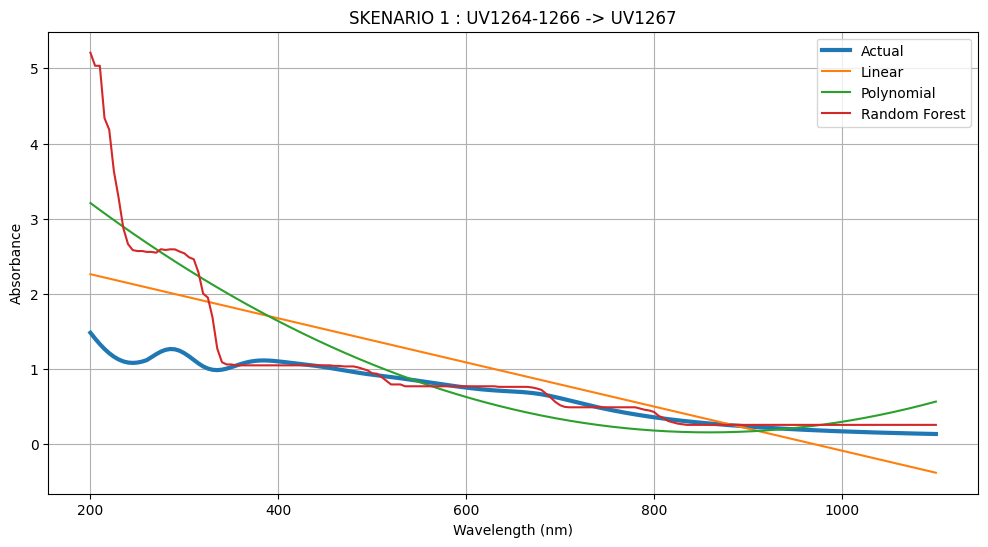

In [7]:
train_s1 = df.iloc[0:3]

test_s1 = df.iloc[3:4]

hasil_s1 = run_scenario(
    train_s1,
    test_s1,
    "SKENARIO 1 : UV1264-1266 -> UV1267"
)

Skenario 2
Data Train: UV 1264 - UV 1267
Data Test: UV 1268



SCENARIO 2 : UV1264-1267 -> UV1268
Total Data Training : (724, 1)
Total Data Testing : (181, 1)

Train : (651, 1)
Validation : (73, 1)

=== Linear Regression ===

VALIDATION
R² : 0.44933239987076357
RMSE : 0.40499630062706327

TEST
R² : -0.7511374628275647
RMSE : 0.4249901695798982

=== Polynomial Regression ===

VALIDATION
R² : 0.4727417085856621
RMSE : 0.3962944616820864

TEST
R² : -1.6322531391716724
RMSE : 0.521053828278428

=== Random Forest ===

VALIDATION
R² : 0.5702496340030065
RMSE : 0.3577786505006412

TEST
R² : -2.6424720196474776
RMSE : 0.6129384660155326


                   Model  R2 Validation  RMSE Validation   R2 Test  RMSE Test
0      Linear Regression       0.449332         0.404996 -0.751137   0.424990
1  Polynomial Regression       0.472742         0.396294 -1.632253   0.521054
2          Random Forest       0.570250         0.357779 -2.642472   0.612938


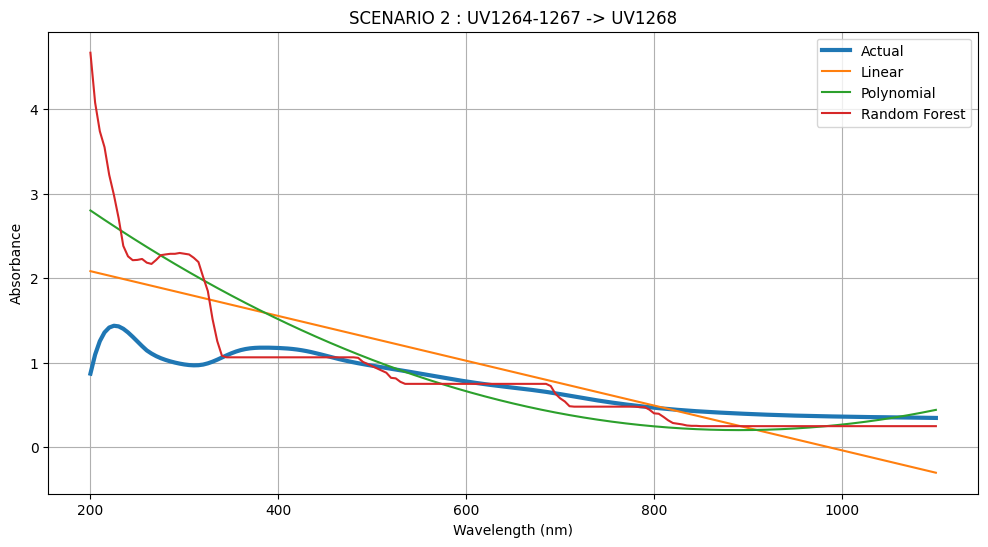

In [8]:
train_s2 = df.iloc[0:4]

test_s2 = df.iloc[4:5]

hasil_s2 = run_scenario(
    train_s2,
    test_s2,
    "SCENARIO 2 : UV1264-1267 -> UV1268"
)